# Shapash Tutorial - NLP Explainability with TF-IDF Classification

This tutorial shows how to build a text classification model with **TF-IDF + Logistic Regression** and explain its predictions with **Shapash**.

You will learn how to:
- prepare a simple NLP dataset,
- train and evaluate a TF-IDF classifier,
- inspect model behavior globally (important terms),
- interpret a single prediction locally with Shapash.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

from shapash import SmartExplainer

## 1. Build a small text classification dataset

We create a synthetic but realistic binary dataset:
- `satisfied`: positive customer feedback
- `frustrated`: negative customer feedback

We also add a subset of **mitigated / mixed-sentiment** messages (both pros and cons) to make some cases intentionally harder to classify.

In [2]:
rng = np.random.default_rng(42)

positive_templates = [
    "The product is {adj} and the support team was {support}.",
    "I had a {adj} experience, delivery was {delivery}.",
    "Everything worked {adv}, setup was {setup}.",
    "Great quality and {adj} customer care.",
]

negative_templates = [
    "The product is {adj} and support was {support}.",
    "I had a {adj} experience, delivery was {delivery}.",
    "Nothing worked {adv}, setup was {setup}.",
    "Poor quality and {adj} customer care.",
]

mitigated_templates = [
    "The product is {pos_adj} but delivery was {neg_delivery}.",
    "Support was {pos_support}, however setup felt {neg_setup}.",
    "The experience was {mix_adj}: quality was good, but service was {neg_support}.",
    "Delivery was {pos_delivery}, yet overall usage remained {neg_adj}.",
    "I can see value in it, although some steps were {neg_setup}.",
]

positive_words = {
    "adj": ["excellent", "great", "reliable", "smooth"],
    "support": ["helpful", "responsive", "professional"],
    "delivery": ["fast", "on time", "perfect"],
    "adv": ["perfectly", "very well", "flawlessly"],
    "setup": ["easy", "quick", "straightforward"],
}

negative_words = {
    "adj": ["bad", "awful", "unreliable", "frustrating"],
    "support": ["slow", "unhelpful", "absent"],
    "delivery": ["late", "delayed", "messy"],
    "adv": ["poorly", "badly", "inconsistently"],
    "setup": ["confusing", "hard", "broken"],
}

mitigated_words = {
    "pos_adj": ["useful", "promising", "decent"],
    "pos_support": ["kind", "available", "responsive"],
    "pos_delivery": ["on time", "acceptable", "fast"],
    "mix_adj": ["mixed", "acceptable", "inconsistent"],
    "neg_adj": ["frustrating", "rough", "unclear"],
    "neg_support": ["slow", "inconsistent", "hard to reach"],
    "neg_delivery": ["late", "unpredictable", "delayed"],
    "neg_setup": ["confusing", "hard", "not straightforward"],
}

label_map = {0: "frustrated", 1: "satisfied"}

def sample_sentence(template, vocab):
    return template.format(
        adj=rng.choice(vocab["adj"]),
        support=rng.choice(vocab["support"]),
        delivery=rng.choice(vocab["delivery"]),
        adv=rng.choice(vocab["adv"]),
        setup=rng.choice(vocab["setup"]),
    )

def sample_mitigated(template, vocab):
    return template.format(
        pos_adj=rng.choice(vocab["pos_adj"]),
        pos_support=rng.choice(vocab["pos_support"]),
        pos_delivery=rng.choice(vocab["pos_delivery"]),
        mix_adj=rng.choice(vocab["mix_adj"]),
        neg_adj=rng.choice(vocab["neg_adj"]),
        neg_support=rng.choice(vocab["neg_support"]),
        neg_delivery=rng.choice(vocab["neg_delivery"]),
        neg_setup=rng.choice(vocab["neg_setup"]),
    )

n_samples_per_class = 700
n_mitigated = 350
texts = []
labels = []
is_mitigated = []

for _ in range(n_samples_per_class):
    texts.append(sample_sentence(rng.choice(positive_templates), positive_words))
    labels.append(1)
    is_mitigated.append(0)

for _ in range(n_samples_per_class):
    texts.append(sample_sentence(rng.choice(negative_templates), negative_words))
    labels.append(0)
    is_mitigated.append(0)

# Add mixed-sentiment feedback with balanced labels to create harder boundary cases.
for i in range(n_mitigated):
    texts.append(sample_mitigated(rng.choice(mitigated_templates), mitigated_words))
    labels.append(1 if i < n_mitigated // 2 else 0)
    is_mitigated.append(1)

nlp_df = pd.DataFrame({"text": texts, "label": labels, "is_mitigated": is_mitigated})
nlp_df["label_name"] = nlp_df["label"].map(label_map)
nlp_df = nlp_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
nlp_df.head()

,text,label,is_mitigated,label_name
0,Poor quality and frustrating customer care.,0,0,frustrated
1,Poor quality and awful customer care.,0,0,frustrated
2,"I had a smooth experience, delivery was perfect.",1,0,satisfied
3,"I had a awful experience, delivery was late.",0,0,frustrated
4,"Support was available, however setup felt not ...",1,1,satisfied


## 2. Train a TF-IDF + Logistic Regression classifier

In [3]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    nlp_df["text"],
    nlp_df["label"],
    test_size=0.25,
    random_state=42,
    stratify=nlp_df["label"],
)

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=800,
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)
feature_names = vectorizer.get_feature_names_out()

# Fit with named columns to avoid sklearn feature-name warnings downstream.
X_train_tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=feature_names,
    index=X_train_text.index,
)
X_test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=feature_names,
    index=X_test_text.index,
)

clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_tfidf_df, y_train)

y_pred = clf.predict(X_test_tfidf_df)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print("Classification report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=[label_map[0], label_map[1]],
    )
)

Accuracy: 0.900

Classification report:

              precision    recall  f1-score   support

  frustrated       0.86      0.95      0.90       219
   satisfied       0.94      0.85      0.89       219

    accuracy                           0.90       438
   macro avg       0.90      0.90      0.90       438
weighted avg       0.90      0.90      0.90       438



## 3. Quick global interpretability from logistic coefficients

Before Shapash, we can inspect the strongest positive/negative TF-IDF terms from the linear model coefficients.

In [4]:
feature_names = vectorizer.get_feature_names_out()
coef = clf.coef_[0]

coef_df = pd.DataFrame({"term": feature_names, "coef": coef}).sort_values("coef")

top_negative = coef_df.head(12).reset_index(drop=True)
top_positive = coef_df.tail(12).sort_values("coef", ascending=False).reset_index(drop=True)

print("Top terms pushing toward class:", label_map[clf.classes_[0]])
display(top_negative)
print("Top terms pushing toward class:", label_map[clf.classes_[1]])
display(top_positive)

Top terms pushing toward class: frustrated


,term,coef
0,poor quality,-2.291052
1,poor,-2.291052
2,bad,-2.025405
3,nothing worked,-2.022134
4,nothing,-2.022134
5,awful,-1.990413
6,and support,-1.983859
7,frustrating,-1.975218
8,unreliable,-1.946076
9,support was,-1.732814


Top terms pushing toward class: satisfied


,term,coef
0,great,3.388834
1,great quality,2.243535
2,everything worked,2.027965
3,everything,2.027965
4,excellent,1.932006
5,smooth,1.884922
6,reliable,1.803459
7,team,1.480375
8,and the,1.480375
9,support team,1.480375


## 4. Explain predictions with Shapash

Shapash expects tabular inputs. For TF-IDF, each term is a feature, so we convert the sparse matrix into a DataFrame with term names as columns.

INFO: Shap explainer type - shap.explainers.PermutationExplainer()


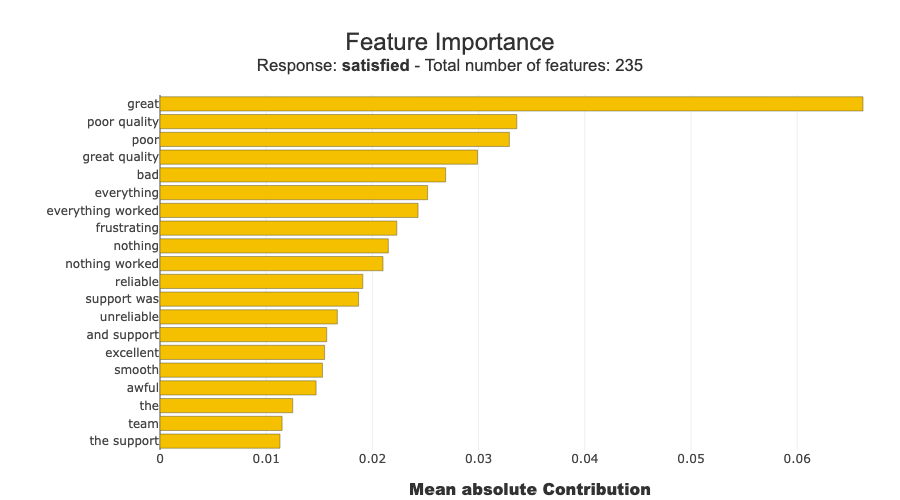

In [5]:
proba_values = pd.DataFrame(
    clf.predict_proba(X_test_tfidf_df)[:, 1],
    columns=[f"proba_{label_map[clf.classes_[1]]}"],
    index=X_test_tfidf_df.index,
)

predicted_code = pd.Series(
    clf.predict(X_test_tfidf_df),
    index=X_test_tfidf_df.index,
    name="predicted_code",
)
predicted_label = predicted_code.map(label_map).rename("predicted_label")

y_pred_numeric = predicted_code.astype(int).to_frame("y_pred")
y_target_numeric = y_test.astype(int).to_frame("y_target")

additional_data = pd.DataFrame({
    "raw_text": X_test_text,
    "is_mitigated": nlp_df.loc[X_test_text.index, "is_mitigated"],
    "true_label": y_test.map(label_map),
    "predicted_label": predicted_label,
})

xpl = SmartExplainer(
    model=clf,
    label_dict={0: "frustrated", 1: "satisfied"},
    title_story="TF-IDF NLP classification explainability",
)
xpl.compile(
    x=X_test_tfidf_df,
    y_pred=y_pred_numeric,
    y_target=y_target_numeric,
    additional_data=additional_data,
    columns_order=["raw_text",
                    "true_label",
                    "predicted_label",
                    ]+X_test_tfidf_df.columns.tolist()
)

xpl.plot.features_importance(max_features=20)

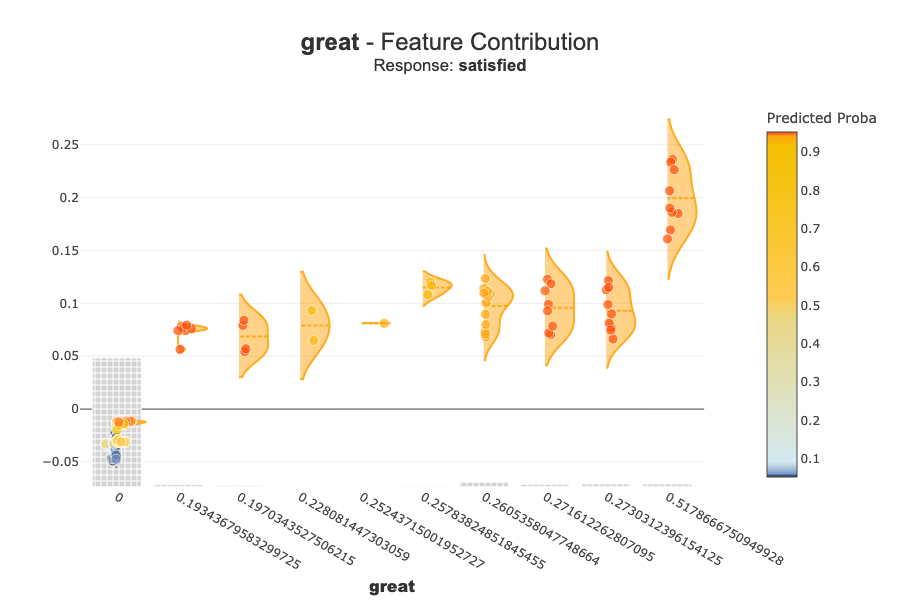

In [6]:
xpl.plot.contribution_plot(col=top_positive.loc[0, "term"])


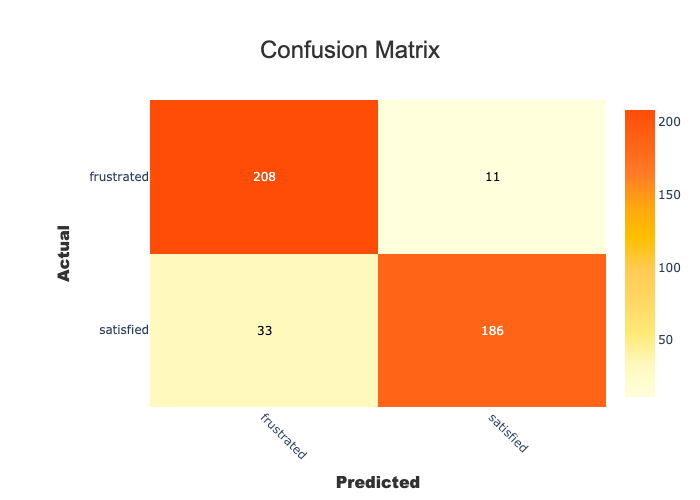

In [7]:
xpl.plot.confusion_matrix_plot()

Explained sample index: 1574


,raw_text,is_mitigated,true_label,predicted_label
1574,"Delivery was on time, yet overall usage remain...",1,satisfied,frustrated


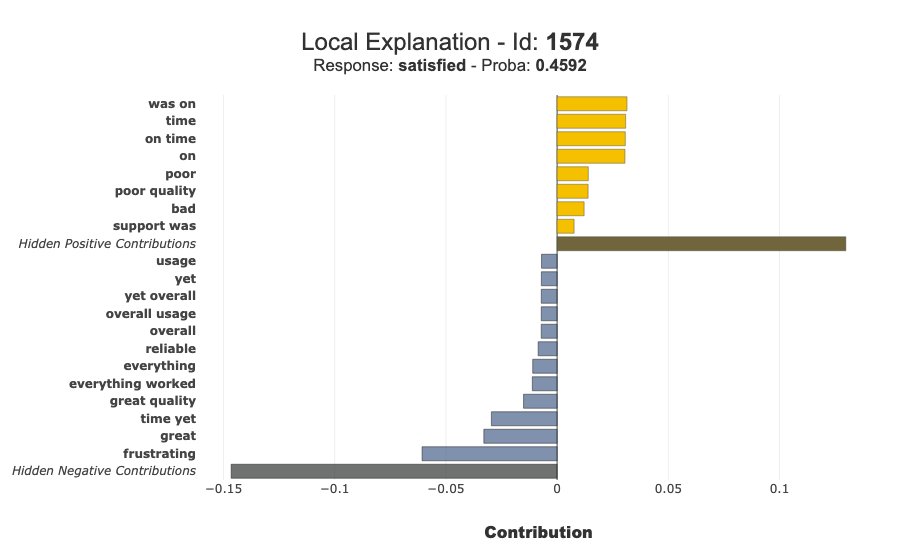

In [8]:
# Prefer a misclassified example for a more insightful local explanation.
test_pred = predicted_code
misclassified_idx = y_test[y_test != test_pred].index

if len(misclassified_idx) > 0:
    sample_idx = misclassified_idx[0]
else:
    # Fallback: pick the closest probability to 0.5.
    confidence_gap = (proba_values.iloc[:, 0] - 0.5).abs()
    sample_idx = confidence_gap.idxmin()

print("Explained sample index:", sample_idx)
display(additional_data.loc[[sample_idx]])
xpl.plot.local_plot(index=sample_idx)

In [9]:
# Optional: launch the interactive Shapash webapp (uncomment to run).
app = xpl.run_app(title_story="TF-IDF NLP classification explainability", port=8060)

INFO:root:Your Shapash application run on http://PMP01087:8060/
INFO:root:Use the method .kill() to down your app.


## 5. Key takeaways

- TF-IDF + Logistic Regression is a strong and interpretable NLP baseline.
- Coefficients provide a first global view of influential terms.
- Shapash helps investigate both global and local prediction drivers in a unified interface.

### Production tips
- Keep vectorizer and model versions aligned (same vocabulary at inference).
- Track vocabulary drift and out-of-vocabulary rate over time.
- Monitor class balance changes and confidence calibration.